In [1]:
import os
import time
import random
import timm
import torchvision
from torchvision import datasets, transforms
import torchvision.models as models
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

def seed_all(seed=123):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

batch_size = 64
seed = 123
seed_all(seed)

simclr_epochs = 200
s_learning_rate = 1e-3

clf_epochs = 50
num_class = 3

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

/home/airl02/anaconda3/envs/socks_torch_2.11.0/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print(torch.cuda.is_available())
print(torch.__version__)
print(torch.version.cuda)

True
2.11.0+cu128
12.8


In [3]:
# Part1.Dataset

from pathlib import Path
from typing import List, Sequence, Optional
from PIL import Image, ImageOps
from torch.utils.data import Dataset
from torchvision import transforms
from torchvision.transforms import functional as TF

class Clsdata(Dataset):
    def __init__(
        self,
        root_list: Sequence[str], # front images path list
        cls_to_idx,
        shuffle: bool = True,
        transform=None,
        train: bool = False,
        test: bool = False,
        img_size: int = 224,
    ):
        assert not (train and test), "Both train and test cannot be True at the same time"
        self.test = test
        self.train = train
        self.img_size = int(img_size)

        lines: List[Path] = [Path(p) for p in root_list]
        if shuffle:
            random.shuffle(lines)
        self.lines = lines
        self.nSamples = len(self.lines)

        self.mean = (0.485, 0.456, 0.406)
        self.std  = (0.229, 0.224, 0.225)

        if transform is None:
            if self.train and not self.test:
                self.transform = None
            else:
                # val / test：
                self.transform = transforms.Compose([
                    transforms.Resize((self.img_size, self.img_size)),
                    transforms.ToTensor(),
                    transforms.Normalize(self.mean, self.std),
                ])
        else:
            self.transform = transform

        self.cls_to_idx = cls_to_idx
        self.idx_to_cls = {v: k for k, v in self.cls_to_idx.items()}

    def __len__(self):
        return self.nSamples

    def _pair_transform(self, img1_pil: Image.Image, img2_pil: Image.Image):
        img1 = ImageOps.exif_transpose(img1_pil)
        img2 = ImageOps.exif_transpose(img2_pil)

        img1 = TF.resize(img1, [self.img_size, self.img_size])
        img2 = TF.resize(img2, [self.img_size, self.img_size])

        if random.random() < 0.5:
            img1 = TF.hflip(img1)
            img2 = TF.hflip(img2)

        if random.random() < 0.5:
            img1 = TF.vflip(img1)
            img2 = TF.vflip(img2)

        if random.random() < 0.8:
            b = 1.0 + random.uniform(-0.2, 0.2)  # brightness factor
            c = 1.0 + random.uniform(-0.2, 0.2)  # contrast factor
            s = 1.0 + random.uniform(-0.2, 0.2)  # saturation factor
            h = random.uniform(-0.05, 0.05)      # hue delta

            img1 = TF.adjust_brightness(img1, b); img2 = TF.adjust_brightness(img2, b)
            img1 = TF.adjust_contrast(img1, c);   img2 = TF.adjust_contrast(img2, c)
            img1 = TF.adjust_saturation(img1, s); img2 = TF.adjust_saturation(img2, s)
            img1 = TF.adjust_hue(img1, h);        img2 = TF.adjust_hue(img2, h)

        # ToTensor + Normalize
        img1 = TF.to_tensor(img1); img2 = TF.to_tensor(img2)
        img1 = TF.normalize(img1, self.mean, self.std)
        img2 = TF.normalize(img2, self.mean, self.std)
        return img1, img2

    def __getitem__(self, index: int):
        assert 0 <= index < len(self), f'index out of range: {index} / {len(self)}'

        img_path = self.lines[index]
        # front / side
        img1_path = img_path
        img2_path = Path(str(img_path).replace("front.jpg", "side.jpg"))

        img1_pil = Image.open(img1_path).convert('RGB')
        img2_pil = Image.open(img2_path).convert('RGB')

        if self.train and not self.test and self.transform is None:
            img1, img2 = self._pair_transform(img1_pil, img2_pil)
        else:
            img1  = self.transform(img1_pil)
            img2 = self.transform(img2_pil)

        class_name = Path(img_path).parent.parent.name
        label = self.cls_to_idx[class_name]

        return img1, img2, label

In [4]:
# Part2. train/val/test 분할

from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

train_root = r"/home/airl02/Desktop/ParkJeongEun/PediURF/train"
test_root = r"/home/airl02/Desktop/ParkJeongEun/PediURF/test"

cls_to_idx = {
    "Proximal ulna and radius fractures": 0,
    "Midshaft ulna and radius fractures": 1,
    "Distal ulna and radius fractures": 2,
}

def get_all_imgs_path(root: str):
  root = Path(root)
  all_front_path = [str(p) for p in root.rglob("front.jpg")]
  return all_front_path

def get_label_from_path(img_path: str):
  path = Path(img_path)
  class_name = path.parent.parent.name

  if class_name not in cls_to_idx:
    raise ValueError(f"Unknown class folder name: {class_name}")

  return cls_to_idx[class_name]

def make_stratified_split(train_root, val_ratio=0.2, seed=123):
  all_imgs_path = get_all_imgs_path(train_root)

  all_labels = [get_label_from_path(p) for p in all_imgs_path]

  train_imgs_path, val_imgs_path = train_test_split(
      all_imgs_path,
      test_size=val_ratio,
      random_state=seed,
      stratify=all_labels
  )

  return train_imgs_path, val_imgs_path

# 8:2 split
train_imgs_path, val_imgs_path = make_stratified_split(
    train_root = train_root,
    val_ratio=0.2,
    seed=seed
)

test_imgs_path = get_all_imgs_path(test_root)

train_data = Clsdata(train_imgs_path, cls_to_idx, train=True, shuffle=True)
val_data  = Clsdata(val_imgs_path, cls_to_idx, train=False, shuffle=False, test=True)
test_data = Clsdata(test_imgs_path, cls_to_idx, train=False, shuffle=False, test=True)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2)

train_length = len(train_data)
val_length  = len(val_data)
test_length = len(test_data)

print(f"train_length: {train_length}")
print(f"val_length: {val_length}")
print(f"test_length: {test_length}")

train_length: 3369
val_length: 843
test_length: 1053


In [5]:
# Part5. Classification
from torchvision.models import ResNet34_Weights

class Classifier(nn.Module):
    def __init__(self, num_classes=3):
        super(Classifier, self).__init__()

        # Encoder(ResNet34)만 추출
        self.encoder = models.resnet34(weights=ResNet34_Weights.DEFAULT)
        self.encoder.fc = nn.Identity()

        self.cross_attention = nn.MultiheadAttention(embed_dim=512, num_heads=8, batch_first=True)

        # 3. 최종 분류기 (MLP)
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x1, x2):
        # 특징 추출 (x1, x2 각각)
        f1 = self.encoder(x1) # [B, 512]
        f2 = self.encoder(x2) # [B, 512]

        features = torch.stack([f1, f2], dim=1)
        attn_output, _ = self.cross_attention(features, features, features)

        x = attn_output.mean(dim=1)

        logits = self.classifier(x)
        return logits

finetune_model = Classifier().to(device)

In [6]:
# 1. Stage 2용 약한 증강 (Weak Augmentation) 정의
finetune_transformer = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

# 2. Validation/Test용 (증강 아예 없음)
test_transformer = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

ft_train_data = Clsdata(train_imgs_path, cls_to_idx, train=False, transform=finetune_transformer)
ft_val_data   = Clsdata(val_imgs_path, cls_to_idx, train=False, transform=test_transformer)
ft_test_data  = Clsdata(test_imgs_path, cls_to_idx, train=False, transform=test_transformer)

ft_train_loader = DataLoader(ft_train_data, batch_size=batch_size, shuffle=True, num_workers=2)
ft_val_loader = DataLoader(ft_val_data, batch_size=batch_size, shuffle=False, num_workers=2)
ft_test_loader  = DataLoader(ft_test_data, batch_size=batch_size, shuffle=False, num_workers=2)

train_length = len(ft_train_data)
val_length  = len(ft_val_data)
test_length = len(ft_test_data)

print(f"train_length: {train_length}")
print(f"val_length: {val_length}")
print(f"test_length: {test_length}")

train_length: 3369
val_length: 843
test_length: 1053


In [7]:
from sklearn.metrics import f1_score
from datetime import datetime

save_name = f"ResNet34_Best_Vanilla_Full_Cross.pth"
best_model_path = os.path.join("/home/airl02/Desktop/ParkJeongEun/Model", save_name)

encoder_lr = 1e-6
classifier_lr = 1e-5

label_smoothing = 0.1

params_to_optimize = [
    {'params': finetune_model.encoder.parameters(), 'lr': encoder_lr},
    {'params': finetune_model.classifier.parameters(), 'lr': classifier_lr}
]

criterion_ce = nn.CrossEntropyLoss(label_smoothing=label_smoothing)
optimizer_ce = torch.optim.Adam(params_to_optimize, weight_decay=1e-2)

scheduler_ce = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_ce, T_max=clf_epochs)

train_losses, val_losses = [], []
best_val_f1 = 0.0

patience = 10
early_stop_counter = 0

start_epoch = 0

if os.path.exists(best_model_path):
  checkpoint = torch.load(best_model_path, map_location=device)

  finetune_model.load_state_dict(checkpoint['model_state_dict'])
  optimizer_ce.load_state_dict(checkpoint['optimizer_state_dict'])
  scheduler_ce.load_state_dict(checkpoint['scheduler_state_dict'])
  start_epoch   = checkpoint.get('epoch', -1) + 1
  train_losses  = checkpoint.get('train_losses', [])
  val_losses    = checkpoint.get('val_losses', [])
  best_val_f1   = checkpoint.get('best_val_f1', 0.0)
  early_stop_counter = checkpoint.get('early_stop_counter', 0)

  print(f"Restart from epoch {start_epoch}")

for epoch in range(start_epoch, clf_epochs):
  finetune_model.train()
  total_train_loss = 0.0

  for img1, img2, label in ft_train_loader:
    img1, img2, label = img1.to(device), img2.to(device), label.to(device)
    optimizer_ce.zero_grad()

    logits = finetune_model(img1, img2)
    loss = criterion_ce(logits, label)
    loss.backward()
    optimizer_ce.step()

    total_train_loss += loss.item() * img1.size(0)

  train_loss = total_train_loss / train_length
  train_losses.append(train_loss)

  scheduler_ce.step()

  finetune_model.eval()
  all_preds, all_labels = [], []
  total_val_loss = 0.0

  with torch.no_grad():
    for img1, img2, label in ft_val_loader:
        img1, img2, label = img1.to(device), img2.to(device), label.to(device)
        logits = finetune_model(img1, img2)

        loss = criterion_ce(logits, label)
        total_val_loss += loss.item() * img1.size(0)

        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(label.cpu().numpy())

  val_f1 = f1_score(all_labels, all_preds, average='weighted')
  val_loss = total_val_loss / val_length
  val_losses.append(val_loss)

  print(f"[{datetime.now().strftime('%H:%M:%S')}] [Epoch {epoch+1}] "
    f"Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val F1: {val_f1:.4f}")

  if best_val_f1 < val_f1:
      best_val_f1 = val_f1
      early_stop_counter = 0

      torch.save({
          'epoch': epoch,
          'model_state_dict': finetune_model.state_dict(),
          'optimizer_state_dict': optimizer_ce.state_dict(),
          'scheduler_state_dict': scheduler_ce.state_dict(),
          'train_losses': train_losses,
          'val_losses': val_losses,
          'best_val_f1': best_val_f1,
          'early_stop_counter': 0
      }, best_model_path)

      print(f"Best model saved! (Val F1: {best_val_f1:.4f})")

  else:
      early_stop_counter += 1

[20:33:25] [Epoch 1] Train Loss: 1.0334, Val Loss: 1.0085, Val F1: 0.4208
Best model saved! (Val F1: 0.4208)
[20:34:14] [Epoch 2] Train Loss: 0.9960, Val Loss: 0.9720, Val F1: 0.5340
Best model saved! (Val F1: 0.5340)
[20:35:02] [Epoch 3] Train Loss: 0.9662, Val Loss: 0.9476, Val F1: 0.5274
[20:35:49] [Epoch 4] Train Loss: 0.9424, Val Loss: 0.9289, Val F1: 0.5172
[20:36:37] [Epoch 5] Train Loss: 0.9225, Val Loss: 0.9143, Val F1: 0.5118
[20:37:27] [Epoch 6] Train Loss: 0.9130, Val Loss: 0.9005, Val F1: 0.5024
[20:38:17] [Epoch 7] Train Loss: 0.9012, Val Loss: 0.8887, Val F1: 0.5024
[20:39:06] [Epoch 8] Train Loss: 0.8889, Val Loss: 0.8798, Val F1: 0.5077
[20:39:52] [Epoch 9] Train Loss: 0.8762, Val Loss: 0.8710, Val F1: 0.5083
[20:40:40] [Epoch 10] Train Loss: 0.8654, Val Loss: 0.8616, Val F1: 0.5136
[20:41:31] [Epoch 11] Train Loss: 0.8558, Val Loss: 0.8519, Val F1: 0.5162
[20:42:18] [Epoch 12] Train Loss: 0.8485, Val Loss: 0.8426, Val F1: 0.5208
[20:43:05] [Epoch 13] Train Loss: 0.836

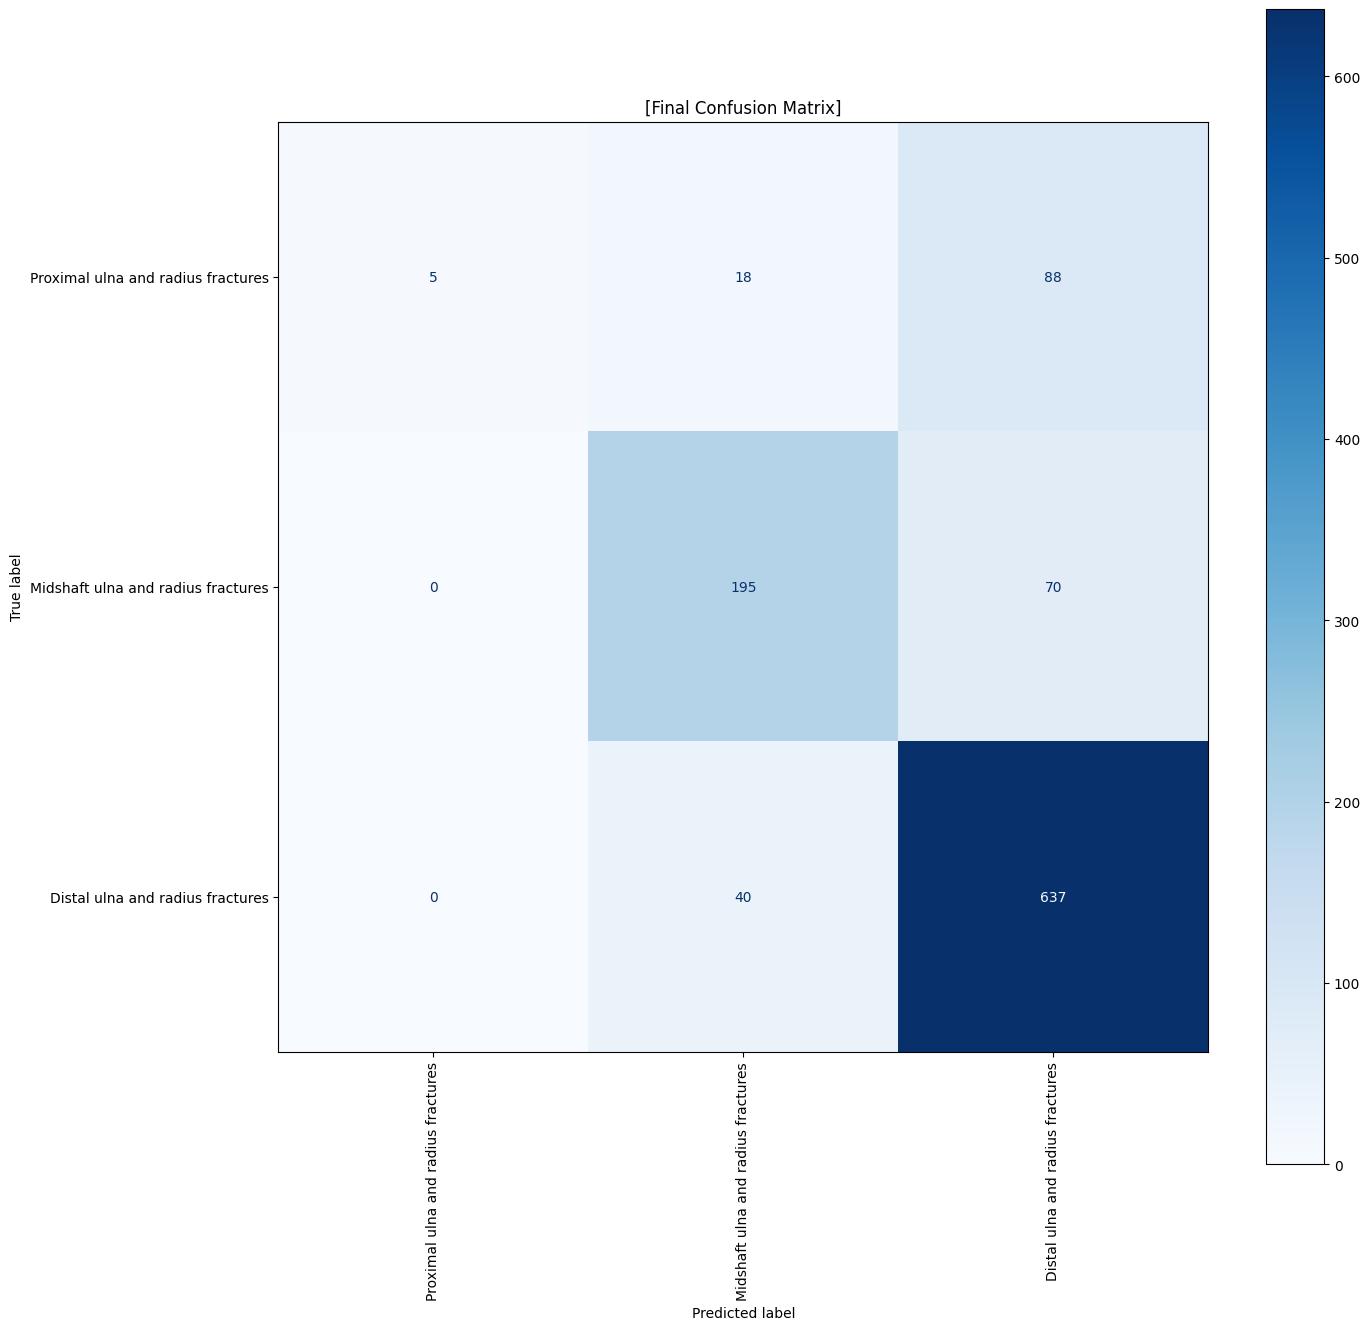


[Classification Report]
                                    precision    recall  f1-score   support

Proximal ulna and radius fractures     1.0000    0.0450    0.0862       111
Midshaft ulna and radius fractures     0.7708    0.7358    0.7529       265
  Distal ulna and radius fractures     0.8013    0.9409    0.8655       677

                          accuracy                         0.7949      1053
                         macro avg     0.8573    0.5739    0.5682      1053
                      weighted avg     0.8145    0.7949    0.7550      1053



In [8]:
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score, precision_score, recall_score, f1_score,roc_auc_score, auc, roc_curve
import matplotlib.pyplot as plt

save_name = f"ResNet34_Best_Vanilla_Full_Cross.pth"
best_model_path = os.path.join("/home/airl02/Desktop/ParkJeongEun/Model", save_name)

checkpoint = torch.load(best_model_path, map_location=device)
finetune_model.load_state_dict(checkpoint['model_state_dict'])
finetune_model.eval()

targets, preds = [], []

with torch.no_grad():
  for img1, img2, label in ft_test_loader:
    img1 = img1.to(device, non_blocking=True)
    img2 = img2.to(device, non_blocking=True)
    label = label.to(device)

    logits = finetune_model(img1, img2)

    _, pred = torch.max(logits, 1)

    targets.extend(label.cpu().tolist())
    preds.extend(pred.cpu().tolist())

idx_to_cls = ft_test_data.idx_to_cls

target_cls = [idx_to_cls[i] for i in targets]
pred_cls = [idx_to_cls[i] for i in preds]

cm = confusion_matrix(target_cls, pred_cls, labels=list(idx_to_cls.values()))
display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(idx_to_cls.values()))

fig, ax = plt.subplots(figsize=(15, 15))
display.plot(cmap='Blues', xticks_rotation='vertical', ax=ax)
plt.title("[Final Confusion Matrix]")
plt.show()

print("\n[Classification Report]")
print(classification_report(
    target_cls,
    pred_cls,
    labels=list(idx_to_cls.values()),
    target_names=list(idx_to_cls.values()),
    digits=4,
    zero_division=0
))

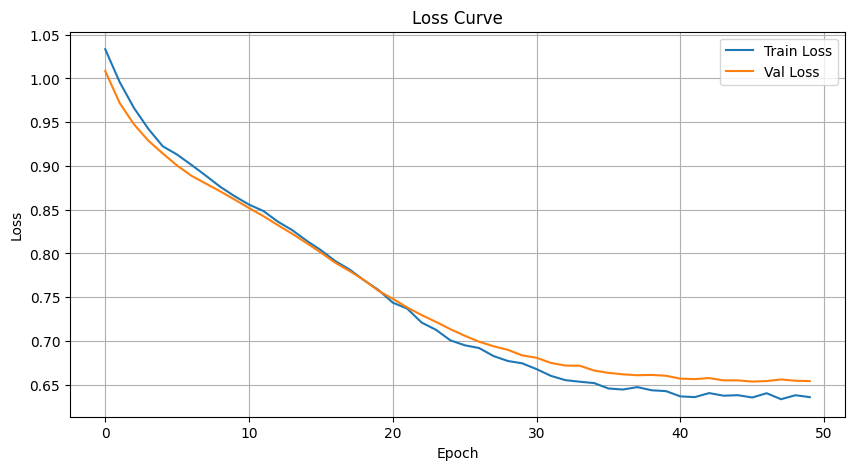

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()
plt.grid(True)
plt.show()